In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2


In [2]:
# ── CELDA 2: Extracción SQL con creación de variable objetivo ──
# Variable objetivo: esta_humedo = 1 si humedad > 65%, 0 si humedad ≤ 65%
# El umbral del 65% se eligió basado en la mediana histórica de humedad

SQL_QUERY = """
SELECT
    c.nombre                              AS ciudad,
    r.temperatura,
    r.sensacion_termica,
    r.humedad,
    r.presion,
    r.velocidad_viento,
    r.fecha_extraccion,
    r.descripcion                         AS descripcion_clima,
    -- Variable objetivo: ¿El ambiente está húmedo?
    -- Umbral: 65% (mediana histórica de humedad)
    CASE
        WHEN r.humedad > 65 THEN 1
        ELSE 0
    END                                   AS esta_humedo
FROM registros_clima r
JOIN ciudades c ON r.ciudad_id = c.id
ORDER BY r.fecha_extraccion;
"""

with engine.connect() as conn:
    df_clima = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_clima.shape[0]:,} filas × {df_clima.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_clima.columns.tolist()}")

print(f"\n⚖️ Balance de la variable objetivo (esta_húmedo):")
bal = df_clima['esta_humedo'].value_counts()
pct = df_clima['esta_humedo'].value_counts(normalize=True) * 100
print(f"   Húmedo (1 - humedad > 65%): {bal.get(1, 0):,}  ({pct.get(1, 0):.1f}%)")
print(f"   Seco   (0 - humedad ≤ 65%): {bal.get(0, 0):,}  ({pct.get(0, 0):.1f}%)")

print(f"\n📊 Estadísticas de humedad:")
print(f"   Media: {df_clima['humedad'].mean():.1f}%")
print(f"   Mediana: {df_clima['humedad'].median():.1f}%")
print(f"   Mínimo: {df_clima['humedad'].min():.1f}%")
print(f"   Máximo: {df_clima['humedad'].max():.1f}%")

print(f"\n🌆 Descripciones únicas de clima:")
print(df_clima['descripcion_clima'].value_counts().head(10))

df_clima.head()

✅ Datos cargados: 5,000 filas × 9 columnas

Columnas disponibles:
['ciudad', 'temperatura', 'sensacion_termica', 'humedad', 'presion', 'velocidad_viento', 'fecha_extraccion', 'descripcion_clima', 'esta_humedo']

⚖️ Balance de la variable objetivo (esta_húmedo):
   Húmedo (1 - humedad > 65%): 1,166  (23.3%)
   Seco   (0 - humedad ≤ 65%): 3,834  (76.7%)

📊 Estadísticas de humedad:
   Media: 50.5%
   Mediana: 47.0%
   Mínimo: 13.0%
   Máximo: 95.0%

🌆 Descripciones únicas de clima:
descripcion_clima
N/A    5000
Name: count, dtype: int64


,ciudad,temperatura,sensacion_termica,humedad,presion,velocidad_viento,fecha_extraccion,descripcion_clima,esta_humedo
0,Oklahoma,24.79,24.92,61,1020,5.83,2026-04-10 12:34:27.887472,N/A,0
1,Bismarck,20.52,20.19,60,1024,3.64,2026-04-10 12:34:27.887661,N/A,0
2,Tomah,7.92,5.48,52,1026,3.93,2026-04-10 12:34:27.887738,N/A,0
3,Taylor Springs,20.56,19.32,25,1015,3.26,2026-04-10 12:34:27.887799,N/A,0
4,Running Springs,10.51,9.26,63,1014,5.83,2026-04-10 12:34:27.887898,N/A,0


In [3]:
# ── CELDA 3: Validación y Exploración ─────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_clima.dtypes.to_frame('dtype').join(
    df_clima.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df_clima['esta_humedo'].value_counts()
pct     = df_clima['esta_humedo'].value_counts(normalize=True) * 100
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Húmedo (1): {balance.get(1, 0):>5,}  ({pct.get(1, 0):.1f}%)")
print(f"   Seco   (0): {balance.get(0, 0):>5,}  ({pct.get(0, 0):.1f}%)")



VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                            dtype  nulos
ciudad                     object      0
temperatura               float64      0
sensacion_termica         float64      0
humedad                     int64      0
presion                     int64      0
velocidad_viento          float64      0
fecha_extraccion   datetime64[ns]      0
descripcion_clima          object      0
esta_humedo                 int64      0

🎯 Balance de la variable objetivo:
   Húmedo (1): 1,166  (23.3%)
   Seco   (0): 3,834  (76.7%)


In [4]:
# ── CELDA 4: Preprocesamiento completo ────────────────────────
df = df_clima.copy()

# 4.1 Features de fecha
df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])

df['mes'] = df['fecha_extraccion'].dt.month

df['dia_semana'] = df['fecha_extraccion'].dt.dayofweek

# 4.2 Relleno de nulos
num_cols = [
    'temperatura',
    'sensacion_termica',
    'presion',
    'velocidad_viento'
]

for col in num_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )

# 4.3 One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['ciudad'],
    drop_first=True,
    dtype=int
)

# 4.4 Variables predictoras
drop_cols = [
    'esta_humedo',
    'humedad',
    'fecha_extraccion',
    'descripcion_clima'
]

X_raw = df.drop(columns=drop_cols)

y = df['esta_humedo']

# 4.5 Variables a escalar
scale_cols = [
    'temperatura',
    'sensacion_termica',
    'presion',
    'velocidad_viento',
    'mes',
    'dia_semana'
]

# 4.6 Escalado
scaler = StandardScaler()

X_scaled = X_raw.copy()

X_scaled[scale_cols] = scaler.fit_transform(
    X_raw[scale_cols]
)

# ── Resumen ───────────────────────────────────────────────────
print("✅ Preprocesamiento completado")

print(f"\n📐 Shape X_scaled: {X_scaled.shape}")

print(
    f"\n🏙️ Variables creadas por ciudad: "
    f"{sum(X_scaled.columns.str.startswith('ciudad_'))}"
)

print("\n📋 Variables numéricas principales:")

print(scale_cols)

print(
    f"\n🎯 Clases en y → "
    f"0 (Seco): {(y==0).sum():,}  |  "
    f"1 (Húmedo): {(y==1).sum():,}"
)

print(
    f"\n📊 Balance: {(y==1).mean()*100:.1f}% es Húmedo"
)

print(
    "\n✅ StandardScaler aplicado correctamente"
)

✅ Preprocesamiento completado

📐 Shape X_scaled: (5000, 1691)

🏙️ Variables creadas por ciudad: 1685

📋 Variables numéricas principales:
['temperatura', 'sensacion_termica', 'presion', 'velocidad_viento', 'mes', 'dia_semana']

🎯 Clases en y → 0 (Seco): 3,834  |  1 (Húmedo): 1,166

📊 Balance: 23.3% es Húmedo

✅ StandardScaler aplicado correctamente


In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):
    """
    Entrena LogisticRegression con un split train/test y devuelve
    un dict con métricas + datos para curva ROC.
    
    Nota: class_weight='balanced' compensa el desbalance entre clases
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced'   # compensa desbalance
    )
    modelo.fit(X_train, y_train)

    y_pred      = modelo.predict(X_test)
    y_prob      = modelo.predict_proba(X_test)[:, 1]   # probabilidad clase 1

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        # Para curva ROC y matriz de confusión
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }
    return metricas

print("✅ Función entrenar_evaluar definida correctamente")
print("   · LogisticRegression con class_weight='balanced'")

✅ Función entrenar_evaluar definida correctamente
   · LogisticRegression con class_weight='balanced'


In [6]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)

       MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA       
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20     4,000    1,000  0.9340  0.8127  0.9313  0.8680  0.9786
Split 60/40     3,000    2,000  0.9200  0.7722  0.9313  0.8444  0.9642
Split 70/30     3,500    1,500  0.9313  0.8095  0.9229  0.8625  0.9651


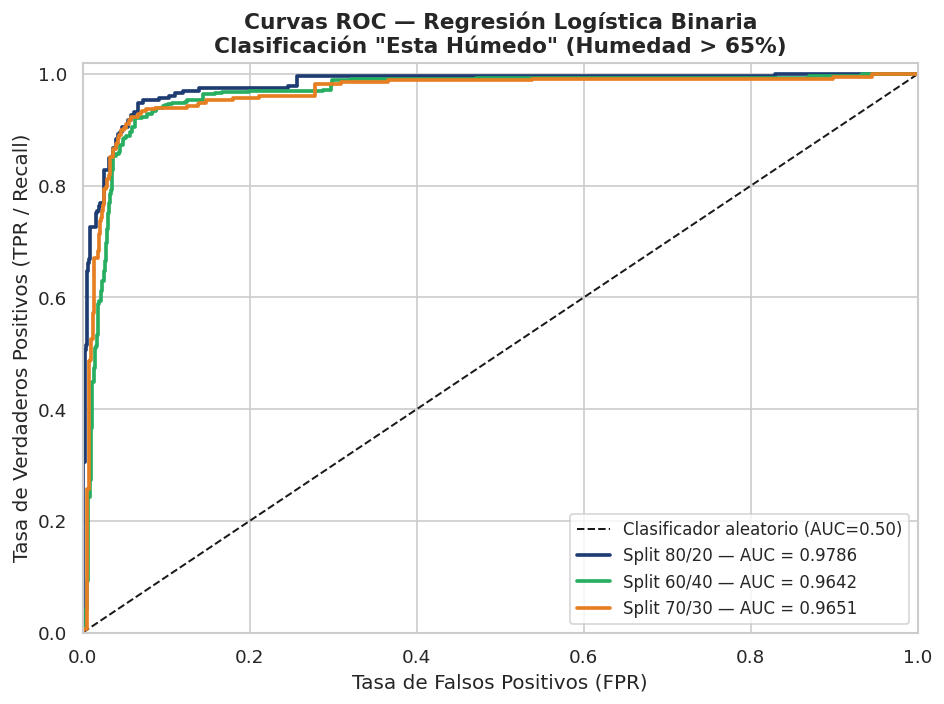

✅ Curvas ROC guardadas en data/graficas/roc_logistica_humedad.png


In [7]:
# ── CELDA 7: Curvas ROC comparativas ──────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
ax.set_title('Curvas ROC — Regresión Logística Binaria\nClasificación "Esta Húmedo" (Humedad > 65%)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../data/graficas/roc_logistica_humedad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas ROC guardadas en data/graficas/roc_logistica_humedad.png")

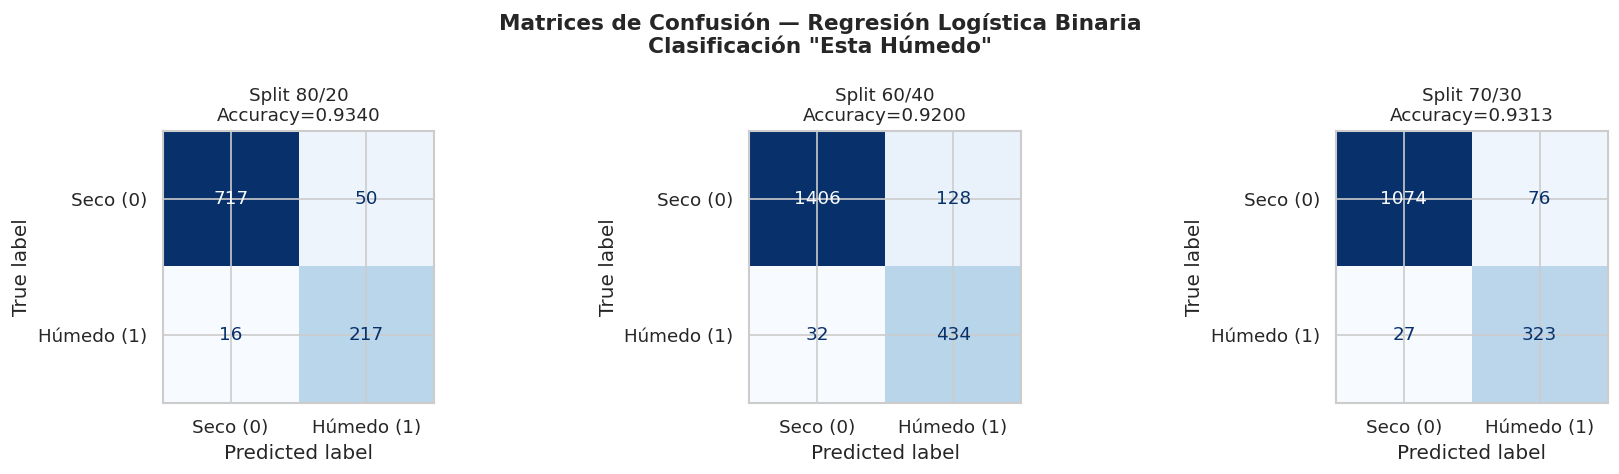

✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_humedad.png


In [8]:
# ── CELDA 8: Matrices de Confusión (3 splits) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Regresión Logística Binaria\nClasificación "Esta Húmedo"', 
             fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Seco (0)', 'Húmedo (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_logistica_humedad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_humedad.png")

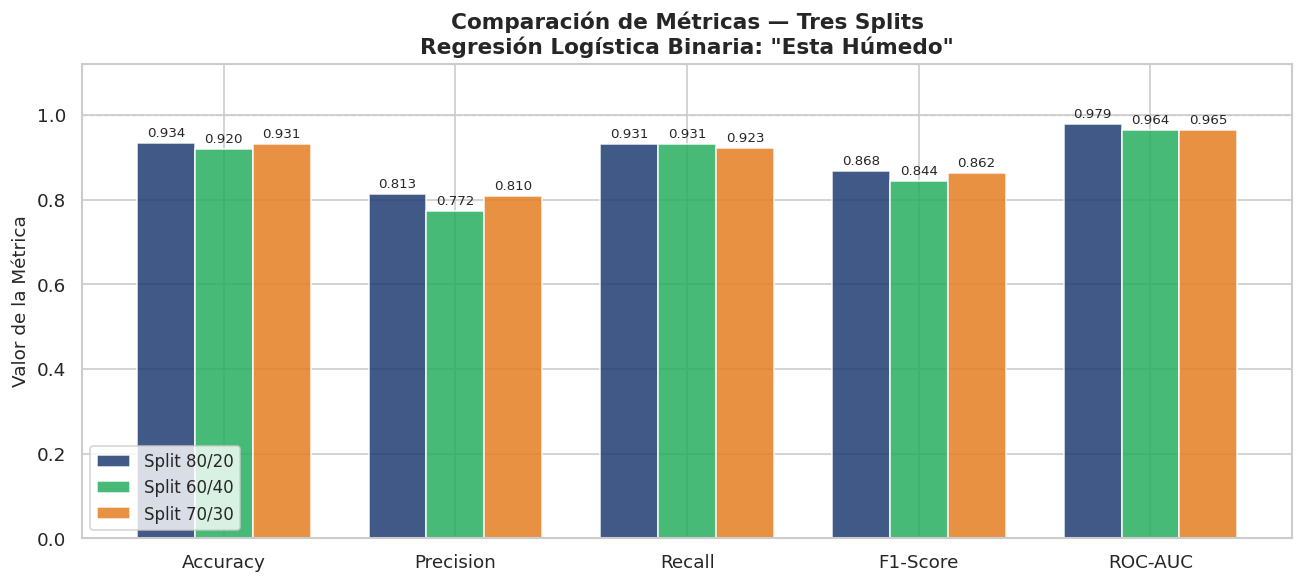

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_humedad.png


In [9]:
# ── CELDA 9: Gráfico comparativo de métricas ──────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nRegresión Logística Binaria: "Esta Húmedo"', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_logistica_humedad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_logistica_humedad.png")

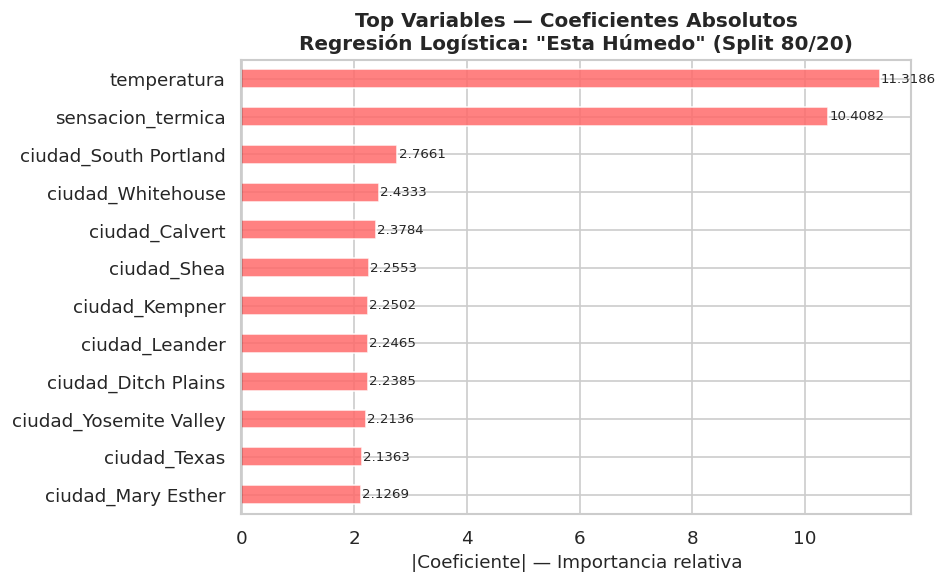

✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_humedad.png


In [10]:
# ── CELDA 10: Importancia de coeficientes (Split 80/20) ────────
modelo_ref = resultados[0]['modelo']
coefs      = pd.Series(modelo_ref.coef_[0], index=X_scaled.columns)
coefs_ord  = coefs.abs().sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
colors_coef = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in coefs_ord]
coefs_ord.plot(kind='barh', ax=ax, color=colors_coef, alpha=0.85)
ax.set_xlabel('|Coeficiente| — Importancia relativa', fontsize=11)
ax.set_title('Top Variables — Coeficientes Absolutos\nRegresión Logística: "Esta Húmedo" (Split 80/20)', 
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Anotar valores
for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(width + 0.02, patch.get_y() + patch.get_height() / 2,
                f'{width:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_logistica_humedad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_humedad.png")

In [11]:
# ── CELDA 11: DataFrame resumen de métricas ───────────────────
resumen = pd.DataFrame([{
    'Split'             : r['nombre'],
    'N Entrenamiento'   : r['train_size'],
    'N Prueba'          : r['test_size'],
    'Accuracy'          : round(r['accuracy'], 4),
    'Precision'         : round(r['precision'], 4),
    'Recall'            : round(r['recall'], 4),
    'F1-Score'          : round(r['f1'], 4),
    'ROC-AUC'           : round(r['roc_auc'], 4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("\n" + "=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print("=" * 65)
display(resumen.style
    .background_gradient(cmap='Blues', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Regresión Logística Binaria — Clasificación 'Esta Húmedo' (Humedad > 65%)")
)

print(f"\n📊 Promedio de métricas entre splits:")
print(f"   Accuracy promedio: {resumen['Accuracy'].mean():.4f}")
print(f"   F1-Score promedio: {resumen['F1-Score'].mean():.4f}")
print(f"   ROC-AUC promedio:  {resumen['ROC-AUC'].mean():.4f}")


                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,4000,1000,0.9340,0.8127,0.9313,0.8680,0.9786
Split 60/40,3000,2000,0.9200,0.7722,0.9313,0.8444,0.9642
Split 70/30,3500,1500,0.9313,0.8095,0.9229,0.8625,0.9651



📊 Promedio de métricas entre splits:
   Accuracy promedio: 0.9284
   F1-Score promedio: 0.8583
   ROC-AUC promedio:  0.9693
